# Ames Housing — Linear Regression From Scratch (PyTorch + scikit-learn)

**Goal of this notebook:** predict `SalePrice` for houses in the Ames, Iowa housing
dataset using linear regression — implemented twice, once by hand in raw PyTorch
(manual tensors, manual gradient descent loop) and once with scikit-learn, to
verify the from-scratch version against a trusted library result at every stage.

**Dataset:** [Ames Housing dataset](https://raw.githubusercontent.com/STATCowboy/pbidataflowstalk/master/AmesHousing.csv) — 2,930 rows, 82 columns, target column `SalePrice`.

**Why build it twice?** Implementing the model by hand exposes the mechanics —
gradient descent, scaling, convergence, evaluation — that a library call hides.
The scikit-learn implementation runs alongside it as an independent check that
the from-scratch version is correct at every stage.

**Notebook structure:**
1. Load & inspect the raw data
2. Clean missing values (with reasoning for every fill decision)
3. Explore relationships with the target (EDA)
4. Build features deliberately, checking for multicollinearity at each step
5. Model: single feature → multi-feature → categorical encoding → polynomial term → final model
6. Limitations and next steps


## Stage 1 — Load & Inspect

First look at the data: shape, dtypes, and an overall sense of what we're working with.

In [1]:
import pandas as pd
import numpy as np


url = 'https://raw.githubusercontent.com/STATCowboy/pbidataflowstalk/master/AmesHousing.csv'
df = pd.read_csv(url)
print(df.shape)
print(df.info())

(2930, 82)
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style   

**Finding:** 2,930 rows, 82 columns. A near-even split between numeric and
categorical columns (confirmed later: 39 numeric, 43 categorical). Target
column is `SalePrice`.

## Stage 2 — Cleaning Missing Values

**Approach:** before filling anything, check *why* a value is missing. In this
dataset, most missingness in categorical columns is **structural** — e.g. a
missing `Pool QC` (Pool Quality) doesn't mean "unknown," it means "this house
doesn't have a pool." Treating structural missingness the same as a true data
gap would be a mistake, so each fill decision below was checked against the
underlying feature it depends on before being applied.

In [2]:
# Missing values
print(df.isnull().sum().loc[lambda x: x > 0].sort_values(ascending=False))

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
BsmtFin Type 1      80
Bsmt Cond           80
Mas Vnr Area        23
Bsmt Half Bath       2
Bsmt Full Bath       2
BsmtFin SF 1         1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
dtype: int64


**Finding:** 21 columns have missing values. The largest gaps (`Pool QC`,
`Misc Feature`, `Alley`, `Fence`, `Fireplace Qu`) are categorical quality/type
columns where a missing value very plausibly means "doesn't have this feature" —
confirmed below by cross-checking against related columns (e.g. does a missing
`Fireplace Qu` line up with `Fireplaces == 0`?) before filling.

**Decision:** fill these 15 categorical columns with the string `'None'` as a
genuine category, not a placeholder for unknown data:
`Pool QC, Misc Feature, Alley, Fence, Fireplace Qu, Mas Vnr Type, Garage Type,
Garage Cond, Garage Finish, Garage Qual, Bsmt Exposure, BsmtFin Type 1,
BsmtFin Type 2, Bsmt Cond, Bsmt Qual`.


In [3]:
none_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu', 'Mas Vnr Type', 'Garage Type', 'Garage Cond', 'Garage Finish', 'Garage Qual', 'Bsmt Exposure',
                'BsmtFin Type 2', 'BsmtFin Type 1', 'Bsmt Cond', 'Bsmt Qual']

df[none_cols] = df[none_cols].fillna('None')

In [4]:
df.isnull().sum().loc[lambda x: x > 0].sort_values(ascending=False)

Lot Frontage      490
Garage Yr Blt     159
Mas Vnr Area       23
Bsmt Half Bath      2
Bsmt Full Bath      2
BsmtFin SF 1        1
BsmtFin SF 2        1
Total Bsmt SF       1
Bsmt Unf SF         1
Garage Cars         1
Garage Area         1
dtype: int64

**Basement numeric columns:** same logic — check whether the missing numeric
basement values line up with `Bsmt Qual == 'None'` (no basement) before filling
with 0. The check surfaced one inconsistency: row 1341 has `NaN` in a basement
numeric column despite `Bsmt Qual == 'None'`; a zero fill is still correct for
that row, and every other row lines up as expected.

In [5]:
# Checking the columns that have missing values in the basement features
cols = ["Bsmt Half Bath","Bsmt Full Bath","BsmtFin SF 1","BsmtFin SF 2","Total Bsmt SF","Bsmt Unf SF"]
sub = df[df['Bsmt Qual'] == 'None']
sub.loc[sub[cols].isna().any(axis=1), ["Bsmt Qual"] + cols]


df[cols] = df[cols].fillna(0)

**Garage columns:** the same structural-missingness question applies, but with
a twist — one row (`2236`) had `Garage Type == 'Detchd'` (a real, named garage
type) while every *other* garage field was missing. That's a contradiction: if
there's genuinely no garage, `Garage Type` itself should also be missing/`None`,
not populated with a specific type. This row needed to be treated as a
**real garage with an incomplete record**, not a "no garage" case.

In [6]:
df.loc[df['Garage Area'].isna(), ['Garage Area', 'Garage Cars', 'Garage Qual', 'Garage Cond', 'Garage Finish', 'Garage Type']]

,Garage Area,Garage Cars,Garage Qual,Garage Cond,Garage Finish,Garage Type
2236,NaN,NaN,None,None,None,Detchd


In [7]:
df.loc[(df['Garage Type'] == 'None') | (df['Garage Type'].isna()), ['Garage Area', 'Garage Cars', 'Garage Qual', 'Garage Cond', 'Garage Finish', 'Garage Type', 'Garage Yr Blt']]

,Garage Area,Garage Cars,Garage Qual,Garage Cond,Garage Finish,Garage Type,Garage Yr Blt
27,0.0,0.0,None,None,None,None,NaN
119,0.0,0.0,None,None,None,None,NaN
125,0.0,0.0,None,None,None,None,NaN
129,0.0,0.0,None,None,None,None,NaN
130,0.0,0.0,None,None,None,None,NaN
...,...,...,...,...,...,...,...
2913,0.0,0.0,None,None,None,None,NaN
2916,0.0,0.0,None,None,None,None,NaN
2918,0.0,0.0,None,None,None,None,NaN
2919,0.0,0.0,None,None,None,None,NaN


**Finding:** every other garage-less row is consistently `0`/`None` across all
garage fields — row 2236 is the *only* row where `Garage Type` is populated but
everything else is missing. This is corroborated by that row's `Sale Condition`
being `'Alloca'` (an unusual sale type), consistent with a real house that simply
has incomplete records rather than no garage at all.

**Decision:** fill row 2236's missing garage fields using the median/mode of
*other* `Garage Type == 'Detchd'` rows only — not the whole dataset — since we
know specifically that this is a detached garage.

In [8]:
det = df[df["Garage Type"] == "Detchd"]

numeric_medians = det[["Garage Area", "Garage Cars"]].median()

cat_modes = det[["Garage Qual", "Garage Cond", "Garage Finish"]].mode().iloc[0]

fill_values = pd.concat([numeric_medians, cat_modes])
df.loc[2236, fill_values.index] = fill_values.values

print(df.loc[2236, ['Garage Area', 'Garage Cars', 'Garage Qual', 'Garage Cond', 'Garage Finish']])

Garage Area      400.0
Garage Cars        2.0
Garage Qual         TA
Garage Cond         TA
Garage Finish      Unf
Name: 2236, dtype: object


The remaining genuinely garage-less rows can now be safely filled with 0,
since row 2236 (the one real exception) has already been handled separately.

In [9]:
df['Garage Area'] = df['Garage Area'].fillna(0)
df['Garage Cars'] = df['Garage Cars'].fillna(0)

**`Garage Yr Blt` — data-entry error.** The column contains a value of `2207`,
outside any plausible range for this dataset. That row's `Year Built` (2006)
and `Yr Sold` (2007) indicate `2207` is a typo for `2007`; it is corrected
below.

In [10]:
df.loc[df["Garage Yr Blt"] == 2207, "Garage Yr Blt"] = 2007
print((df['Garage Yr Blt'] == 2207).sum())

0


For the remaining, genuinely garage-less rows, `Garage Yr Blt` is filled with
that row's own `Year Built` — a deliberate placeholder assumption (a garage-less
house obviously has no garage build year), not a claim of fact. This choice is
documented here specifically so it isn't mistaken for real data later.

In [11]:
df.loc[df['Garage Yr Blt'].isnull(), 'Garage Yr Blt'] = df['Year Built']

A type check confirms `Garage Yr Blt` is uniformly numeric after the fills
above.

In [12]:
df['Garage Yr Blt'].apply(type).value_counts()

Garage Yr Blt
<class 'float'>    2930
Name: count, dtype: int64

**`Lot Frontage`:** 490 missing values, roughly 1 in 6 rows. Instead of a
single global median (which would ignore real neighborhood-level differences in
lot sizes), fill per-neighborhood using each neighborhood's own median — a more
locally accurate estimate than a single dataset-wide number.

In [13]:
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

Two neighborhoods (`GrnHill`, `Landmrk`) had **no** non-missing `Lot Frontage`
values at all, so their group median came back as `NaN` — these few remaining
gaps are filled with the overall dataset median as a fallback.

In [14]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

In [15]:
df.isnull().sum().loc[lambda x: x > 0]

Mas Vnr Area    23
dtype: int64

`Mas Vnr Area` (masonry veneer area) — the last 23 missing values line up
cleanly with `Mas Vnr Type == 'None'` (no masonry veneer), so filling with `0`
is a safe, well-supported final cleaning step.

**Cleaning complete** — `df.isnull().sum()` returns fully empty from this point
on.

## Stage 3 — Exploring Relationships with `SalePrice`

Goal: find which features are worth building into the model, and understand
*why*, before touching any modeling code.

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')
corrs = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print(corrs)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647812
Garage Area        0.640416
Total Bsmt SF      0.632529
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Garage Yr Blt      0.544232
Year Remod/Add     0.532974
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.433147
Lot Frontage       0.353417
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.275823
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.183308
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.006018
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035817
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

**Finding — top correlated numeric features with `SalePrice`:**
`Overall Qual` (0.799), `Gr Liv Area` (0.707), `Garage Cars` (0.648),
`Garage Area` (0.640), `Total Bsmt SF` (0.633), `1st Flr SF` (0.622).

A visual pairplot of these top features (plus `SalePrice`) was reviewed to look
for shape, redundancy, and outliers before deciding what to actually build into
the model.

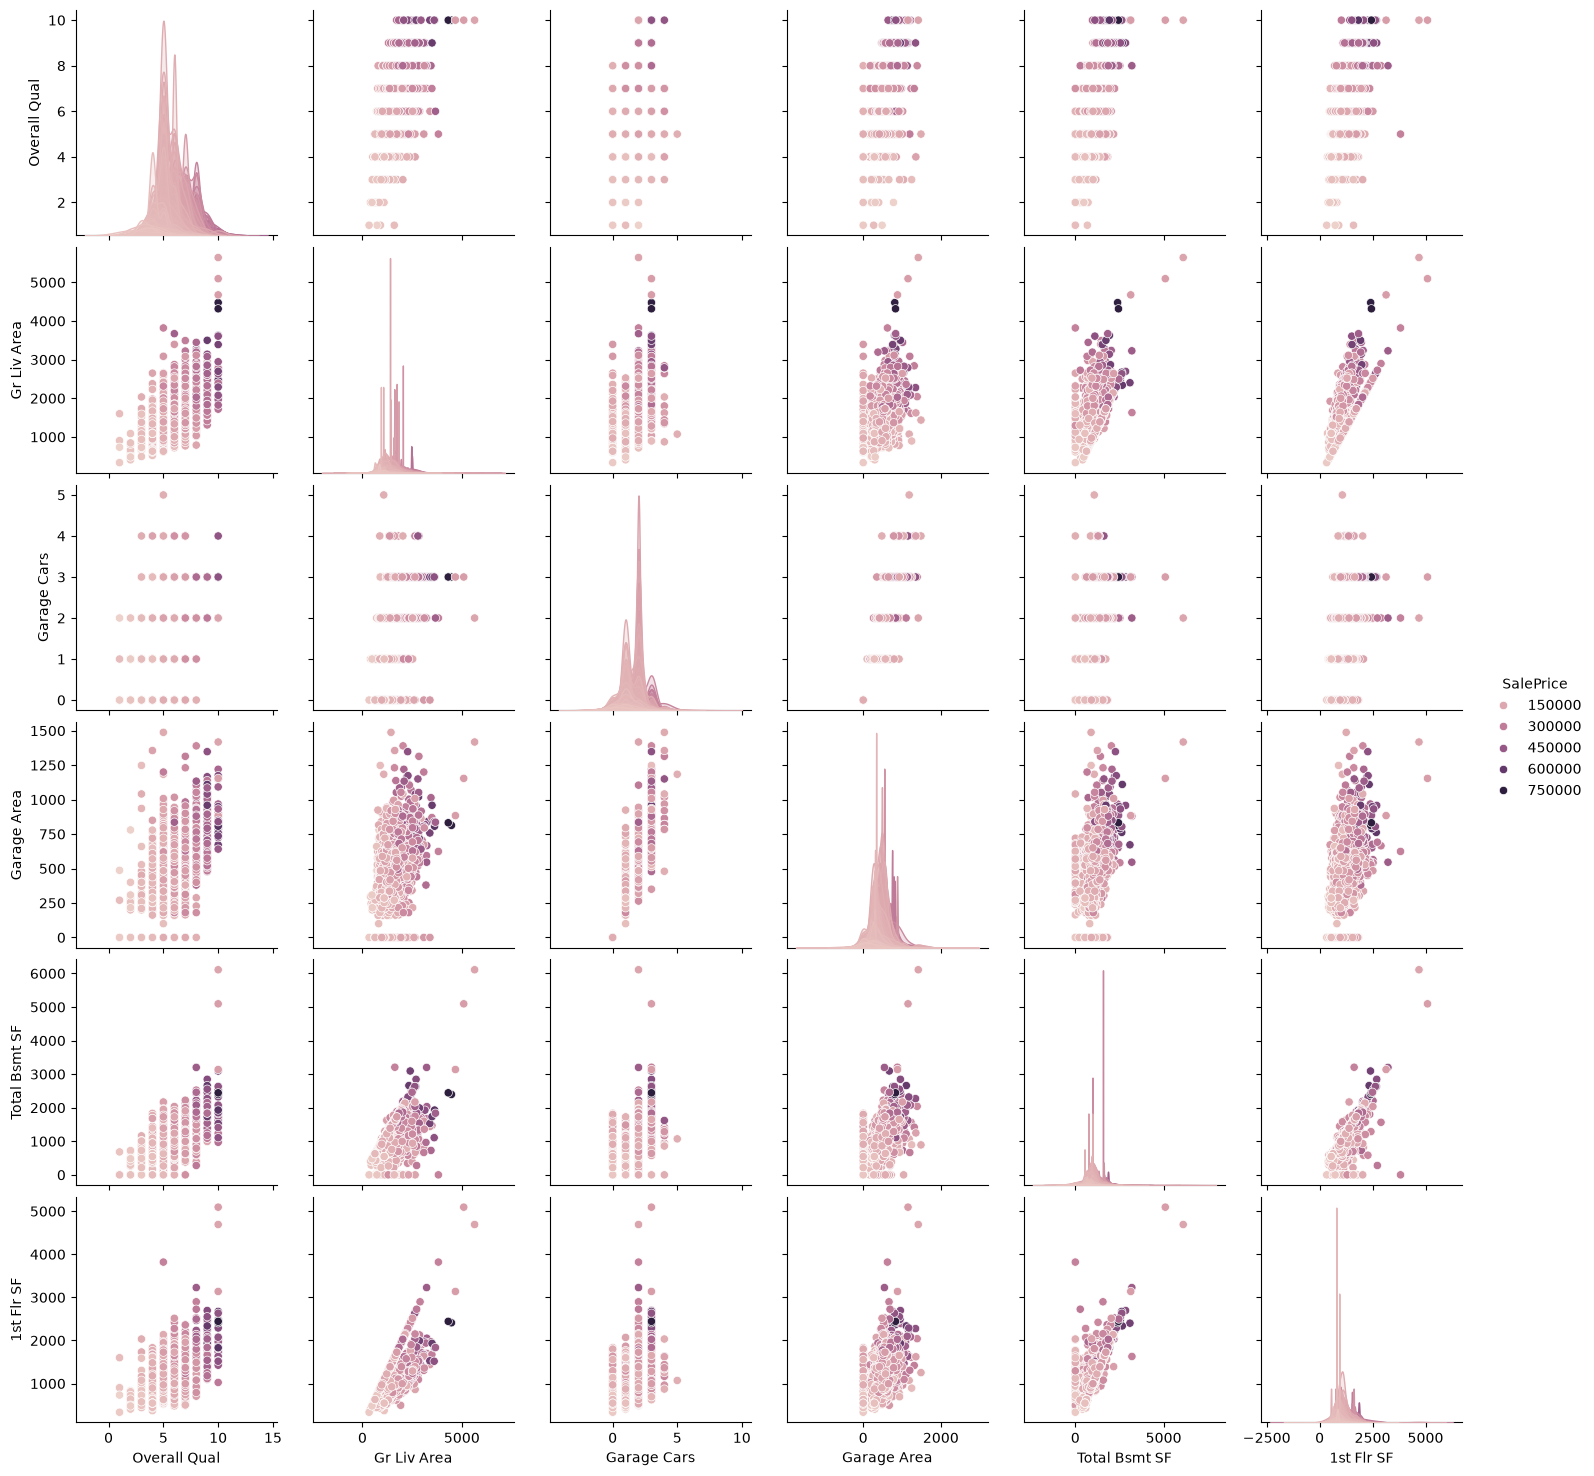

In [17]:
sns.pairplot(df[['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF']], hue='SalePrice')

**Pairplot findings:**
- `Garage Cars` shows discrete horizontal/vertical striping against every other
  feature — expected, since it's a small-integer count variable (0-5), not a
  continuous measurement.
- `Gr Liv Area` vs. `1st Flr SF` shows a **tight diagonal band** for a large
  subset of houses — flagged immediately as a likely multicollinearity risk,
  confirmed numerically later (see Stage 4).
- No extreme, obviously-erroneous outliers stood out in this particular view.


## Stage 4 — Investigating Candidate Features Before Adding Them

Rather than adding every correlated column at once, each candidate feature is
checked against features **already selected** for redundancy — a strong
correlation with `SalePrice` alone doesn't justify inclusion if the feature is
mostly duplicating information another feature already provides.

### `Year Built` vs. existing features

In [18]:
check = df[['Overall Qual', 'Total Bsmt SF', 'Gr Liv Area', 'Year Built']]

check.corr()['Year Built']

Overall Qual     0.597027
Total Bsmt SF    0.407764
Gr Liv Area      0.241726
Year Built       1.000000
Name: Year Built, dtype: float64

**Finding:** moderate correlation with `Overall Qual` (0.597), weak with the
others — some overlap, but not severe enough to exclude `Year Built`.

### `Year Remod/Add` — how much does it duplicate `Year Built`?

In [19]:
((df['Year Remod/Add'] == df['Year Built']).mean())

np.float64(0.5354948805460751)

In [20]:
print(df['Year Remod/Add'].mean()- df['Year Built'].mean())

12.910238907849816


**Finding:** `Year Remod/Add` is **identical** to `Year Built` for 53.5% of
houses (never remodeled) — genuinely redundant for over half the dataset. The
12.9-year average gap between the two columns looked at first like evidence the
columns carry different information throughout, but that's a misleading summary
statistic on its own: a large minority of remodeled houses can pull the *mean*
gap up substantially even while the *majority* of rows are exactly redundant.

**Decision:** exclude `Year Remod/Add` — `Year Built` alone has a higher raw
correlation with `SalePrice` (0.558 vs 0.533) and already captures most of the
same signal.

### `Full Bath` vs. existing features, and a data quality check

In [21]:
df['Full Bath'].value_counts()

Full Bath
2    1532
1    1318
3      64
0      12
4       4
Name: count, dtype: int64

In [22]:
check = df[['Overall Qual', 'Total Bsmt SF', 'Gr Liv Area', 'Full Bath']]
check.corr()['Full Bath'].sort_values(ascending= False)

Full Bath        1.000000
Gr Liv Area      0.630321
Overall Qual     0.522263
Total Bsmt SF    0.325434
Name: Full Bath, dtype: float64

In [23]:
df.loc[df['Full Bath'] == 0, ['Full Bath', 'Half Bath']]

,Full Bath,Half Bath
158,0,0
232,0,1
765,0,1
808,0,2
813,0,2
1385,0,2
1742,0,2
2118,0,1
2279,0,1
2522,0,1


**Findings:**
- `Full Bath` correlates at 0.630 with `Gr Liv Area` — real overlap (bigger
  houses tend to have more bathrooms), but far weaker than the near-perfect
  redundancy found for `Garage Cars`/`Garage Area` or `1st Flr SF`/`Gr Liv Area`
  below — not severe enough to exclude.
- Of the 12 rows with `Full Bath == 0`, 9 have at least one half bath (plausible —
  a small/older house with no full bath), and 3 (`2723`, `2723`... rows `2723`
  and `2880`) have **no bathroom facilities recorded at all**. At only 2 rows out
  of 2,930, this is judged immaterial to the model and left as-is rather than
  investigated further — a deliberate "too small a sample to matter" call,
  the same kind of judgment made earlier for extremely rare `Neighborhood`
  categories.

**Decision:** include `Full Bath`.

### `Garage Cars` vs. `Garage Area` — redundancy check

In [24]:
df.groupby('Garage Cars')['Garage Area'].mean()

Garage Cars
0.0       0.000000
1.0     300.206941
2.0     519.213840
3.0     808.328877
4.0     963.125000
5.0    1184.000000
Name: Garage Area, dtype: float64

In [25]:
df['Garage Cars'].corr(df['Garage Area'])

np.float64(0.8896091485579182)

**Finding:** `Garage Cars` and `Garage Area` correlate at **0.89** with each
other, and the groupby shows a clean, near-linear relationship between garage
capacity and garage square footage — these two columns are measuring almost the
same underlying thing ("how big is the garage"), just in different units.

Their individual correlations with `SalePrice` are close (`Garage Cars` 0.648 vs.
`Garage Area` 0.640) — with two heavily redundant features, the tie-breaker is
simply picking the one with (marginally) stronger target correlation.

**Decision:** keep `Garage Cars`, drop `Garage Area`.

### `1st Flr SF` vs. `Gr Liv Area` — structural redundancy

Flagged visually in the Stage 3 pairplot as a tight diagonal band. Checked
directly: for single-story houses, `2nd Flr SF == 0`, which means
`Gr Liv Area == 1st Flr SF` almost exactly by construction (living area *is*
the first floor, since there is no second floor). For multi-story houses,
`Gr Liv Area = 1st Flr SF + 2nd Flr SF + ...` — so `1st Flr SF` is always
either equal to, or a direct component of, `Gr Liv Area`. This isn't ordinary
correlation — it's a near-deterministic arithmetic relationship for a large
share of the dataset.

**Decision:** drop `1st Flr SF` — its information is already contained within
`Gr Liv Area`.

## Stage 5 — Encoding `Neighborhood`

`Neighborhood` showed a real ~3.6x spread in median `SalePrice` across
neighborhoods during EDA — a categorical feature worth including, but it needs
one-hot encoding to be usable in a linear model, and needs a rare-category
strategy since neighborhood sizes vary hugely (from 443 houses down to a single
house).

In [26]:
df['Neighborhood_fixed'] = df['Neighborhood'].copy()

df['Neighborhood_fixed'] = df['Neighborhood'].mask(df['Neighborhood'].map(df['Neighborhood'].value_counts()) <= 10, 'Other')

**Cutoff choice:** 10, chosen by inspecting the sorted value counts and
finding a natural gap (`Blueste`=10, next smallest jump to `NPkVill`=23) rather
than picking a round number arbitrarily. Neighborhoods with 10 or fewer houses
(`Blueste`, `Greens`, `GrnHill`, `Landmrk`) are folded into an `'Other'` bucket
of 21 houses total — large enough that the model can estimate a stable
coefficient for it, unlike the original `Landmrk` category which had exactly
**one** house.

**Why this matters:** a one-hot column that's `1` for only 1-2 houses gives the
model almost no data to reliably learn that category's effect — its coefficient
could be wildly unstable, or the model may never see that category at all if it
lands only in the validation split.


## Stage 6 — Modeling: Single-Feature Baseline, Then Building Up

The core of the project: build linear regression **twice** — once by hand in raw
PyTorch (writing the training loop manually) and once with scikit-learn — and
verify the two agree, before trusting either.

The very first run below is a full worked example on 3 numeric features
(`Overall Qual`, `Gr Liv Area`, `Garage Cars`) with `Neighborhood` not yet
added, kept here to show the complete pattern before it was wrapped into a
reusable function.

(2930, 3)
(2344, 3) (586, 3)
Epoch 0, MSE: 37837344768.000000
Epoch 10, MSE: 5449816064.000000
Epoch 20, MSE: 1979517952.000000
Epoch 30, MSE: 1554532736.000000
Epoch 40, MSE: 1499566848.000000
Epoch 50, MSE: 1491404928.000000
Epoch 60, MSE: 1489753344.000000
Epoch 70, MSE: 1489257600.000000
Epoch 80, MSE: 1489064960.000000
Epoch 90, MSE: 1488981888.000000


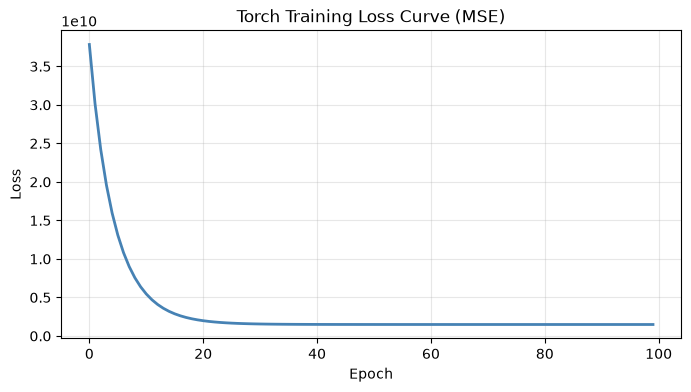

Torch   RMSE: 43858.31 | R^2: 0.7601
Sklearn RMSE: 43850.73 | R^2: 0.7602


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import torch

num_features = ['Overall Qual', 'Gr Liv Area', 'Garage Cars']

X = df[num_features]
y = df[['SalePrice']]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print(X.shape)
print(X_train.shape, X_valid.shape)


x_scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    x_scaler.fit_transform(X_train[num_features]),
    index=X_train.index,
    columns=num_features,
)
X_valid_num_scaled = pd.DataFrame(
    x_scaler.transform(X_valid[num_features]),
    index=X_valid.index,
    columns=num_features,
)

X_train_final = pd.concat([X_train_num_scaled, X_train.drop(columns=num_features)], axis=1)
X_valid_final = pd.concat([X_valid_num_scaled, X_valid.drop(columns=num_features)], axis=1)

X_train_tensor = torch.tensor(X_train_final.to_numpy(dtype='float32'), dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_final.to_numpy(dtype='float32'), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(dtype='float32'), dtype=torch.float32)

# Initialize parameters for linear model y = Xw + b
torch.manual_seed(42)
w = (torch.randn(X_train_tensor.shape[1], 1, dtype=torch.float32) * 0.01).requires_grad_()
b = torch.zeros(1, dtype=torch.float32, requires_grad=True)

criterion = torch.nn.MSELoss()
lr = 0.05
epochs = 100
loss_history = []

for epoch in range(epochs):
    y_pred = X_train_tensor @ w + b
    loss = criterion(y_pred, y_train_tensor)
    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()

    loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, MSE: {loss.item():.6f}")

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue', linewidth=2)
plt.title('Torch Training Loss Curve (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

with torch.no_grad():
    torch_preds = (X_valid_tensor @ w + b).numpy()

# Sklearn baseline on the exact same train/valid features
sk_model = LinearRegression()
sk_model.fit(X_train_final, y_train)
sk_preds = sk_model.predict(X_valid_final)

# Compare both in original units (dollars)
y_valid_np = y_valid.to_numpy()

torch_rmse = root_mean_squared_error(y_valid_np, torch_preds)
torch_r2 = r2_score(y_valid_np, torch_preds)

sk_rmse = root_mean_squared_error(y_valid_np, sk_preds)
sk_r2 = r2_score(y_valid_np, sk_preds)

print(f"Torch   RMSE: {torch_rmse:.2f} | R^2: {torch_r2:.4f}")
print(f"Sklearn RMSE: {sk_rmse:.2f} | R^2: {sk_r2:.4f}")

**Finding:** Torch and sklearn agree almost exactly (\$43,858 vs. \$43,851
RMSE) — strong evidence the hand-written gradient descent loop is mechanically
correct. This run scales only `X`; the reusable function in Stage 7 also scales
`y`, which becomes necessary for stable convergence as the feature count grows.

## Stage 7 — A Reusable `train_and_evaluate` Function

Copy-pasting the block above for every new feature combination is error-prone.
Wrapping the whole pipeline in a function gives every call a fresh split, fresh
scalers, and fresh tensors, and adds the `y` scaling omitted from the single
run above.

The function is defined here; the final-model run that uses it comes after
Stages 8–9, once categorical screening and the polynomial term justify the
remaining features.

In [28]:
def train_and_evaluate(X, y, num_features, epochs=3000, lr=0.1, criterion = torch.nn.MSELoss()):
    """
    X: full feature DataFrame (numeric + already-encoded categorical columns)
    num_features: list of column names that need scaling
    Returns: dict of results (torch_rmse, torch_r2, sk_rmse, sk_r2, loss_history)
    """
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    if len(num_features) > 0:
        X_train_num_scaled = pd.DataFrame(x_scaler.fit_transform(X_train[num_features]), index=X_train.index, columns=num_features)
        X_valid_num_scaled = pd.DataFrame(x_scaler.transform(X_valid[num_features]), index=X_valid.index, columns=num_features)

        X_train_final = pd.concat([X_train_num_scaled, X_train.drop(columns=num_features)], axis=1)
        X_valid_final = pd.concat([X_valid_num_scaled, X_valid.drop(columns=num_features)], axis=1)

    else:
        X_train_final = X_train.copy()
        X_valid_final = X_valid.copy()

    y_train_scaled = y_scaler.fit_transform(y_train)

    X_train_tensor = torch.tensor(X_train_final.to_numpy(dtype = 'float32'), dtype = torch.float32)
    X_valid_tensor = torch.tensor(X_valid_final.to_numpy(dtype = 'float32'), dtype = torch.float32)
    y_train_tensor = torch.tensor(y_train_scaled, dtype = torch.float32)

    torch.manual_seed(42)
    w = (torch.randn(X_train_tensor.shape[1], 1, dtype = torch.float32)* 0.01).requires_grad_()
    b = torch.zeros(1, dtype = torch.float32).requires_grad_()

    loss_history = []

    for epoch in range(epochs):
        y_pred = X_train_tensor @ w + b
        loss = criterion(y_pred, y_train_tensor)
        loss.backward()

        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
            w.grad.zero_()
            b.grad.zero_()

        loss_history.append(loss.item())

        if epoch % 200 == 0:
            print(f"epoch: {epoch}, MSE: {loss.item():.6f}")

    plt.figure(figsize=(10, 4))
    plt.title("Torch Linear Regression Loss")
    plt.plot(loss_history)
    plt.xlabel("epochs")
    plt.ylabel("MSE Loss")
    plt.grid(alpha=0.3)
    plt.show()

    with torch.no_grad():
        torch_preds_scaled = (X_valid_tensor @ w + b).detach().numpy()
        torch_preds = y_scaler.inverse_transform(torch_preds_scaled)

    sk_model = LinearRegression()
    sk_model.fit(X_train_final, y_train)
    sk_preds = sk_model.predict(X_valid_final)

    y_valid_np = y_valid.to_numpy()

    torch_rmse = root_mean_squared_error(y_valid_np, torch_preds)
    torch_r2 = r2_score(y_valid_np, torch_preds)
    sk_rmse = root_mean_squared_error(y_valid_np, sk_preds)
    sk_r2 = r2_score(y_valid_np, sk_preds)

    result = {
        "Torch RMSE": torch_rmse,
        "Torch R2": torch_r2,
        "SK RMSE": sk_rmse,
        "SK R2": sk_r2,
        "n_features_after_encoding": X_train_final.shape[1],
    }

    return result

## Stage 8 — Screening Categorical Features for Target Association

`.corr()` only works between numeric columns. To screen *categorical* columns
(like `Bsmt Qual`, `Exter Qual`, `Kitchen Qual`) for association with
`SalePrice`, a one-way ANOVA F-test plus an eta-squared effect size is used
instead — the categorical equivalent of a correlation coefficient.

In [29]:
from scipy import stats

# Categorical-vs-target association: one-way ANOVA + eta-squared effect size
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
results = []

for col in cat_cols:
    tmp = df[[col, 'SalePrice']].dropna()

    # Keep levels with at least 2 rows so variance is defined
    counts = tmp[col].value_counts()
    valid_levels = counts[counts >= 2].index
    tmp = tmp[tmp[col].isin(valid_levels)]

    groups = [g['SalePrice'].values for _, g in tmp.groupby(col)]
    k = len(groups)
    n = len(tmp)

    if k < 2 or n <= k:
        continue

    # ANOVA F-test
    f_stat, p_value = stats.f_oneway(*groups)

    # Eta-squared effect size for one-way ANOVA
    grand_mean = tmp['SalePrice'].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((tmp['SalePrice'] - grand_mean) ** 2).sum()
    eta_sq = ss_between / ss_total if ss_total > 0 else np.nan

    results.append({
        'feature': col,
        'levels_used': k,
        'n_rows': n,
        'f_stat': f_stat,
        'p_value': p_value,
        'eta_squared': eta_sq
    })

cat_saleprice_assoc = pd.DataFrame(results).sort_values('eta_squared', ascending=False)
cat_saleprice_assoc.head(20)

C:\Users\kwtsu\AppData\Local\Temp\ipykernel_23616\3074782200.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


,feature,levels_used,n_rows,f_stat,p_value,eta_squared
8,Neighborhood,27,2929,149.921885,0.000000e+00,0.573233
43,Neighborhood_fixed,25,2930,161.334233,0.000000e+00,0.571346
21,Bsmt Qual,6,2930,615.920809,0.000000e+00,0.512959
18,Exter Qual,4,2930,993.960715,0.000000e+00,0.504729
30,Kitchen Qual,4,2929,906.747123,0.000000e+00,0.481864
34,Garage Finish,4,2930,433.696751,4.367599e-233,0.307798
32,Fireplace Qu,6,2930,258.538060,2.543386e-229,0.306565
20,Foundation,6,2930,227.567827,1.267124e-205,0.280129
33,Garage Type,7,2930,161.369790,1.665985e-177,0.248821
24,BsmtFin Type 1,7,2930,143.631990,5.579684e-160,0.227699


**Finding:** `Bsmt Qual`, `Exter Qual`, and `Kitchen Qual` all show very high
eta-squared effect sizes — even stronger association than `Neighborhood` —
supporting the addition of `Bsmt Qual` and `Exter Qual` to the model. The
p-values displayed as `0.000000e+00` are a precision artifact of the default
formatting; selection here rests on the effect sizes. `Kitchen Qual`, despite a
comparable effect size, is held out of the final model and remains a candidate
for a future iteration.

### A parallel check: `ColumnTransformer` + `Pipeline`

A separate, smaller experiment using scikit-learn's `ColumnTransformer`/`Pipeline`
tools — the same pattern used previously in an earlier Heart Disease project —
applied here to just `Bsmt Qual` and `Exter Qual` alone (no numeric features),
as a standalone check on how much these two categoricals explain by themselves.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

# One-hot encode selected categorical features, then fit linear regression
cat_features_pipe = ['Bsmt Qual', 'Exter Qual']
target_col = 'SalePrice'

pipe_df = df[cat_features_pipe + [target_col]].dropna().copy()
X_pipe = pipe_df[cat_features_pipe]
y_pipe = pipe_df[target_col]

X_train_pipe, X_valid_pipe, y_train_pipe, y_valid_pipe = train_test_split(
    X_pipe,
    y_pipe,
    test_size=0.2,
    random_state=42,
)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features_pipe),
    ],
    remainder='drop',
)

model_pipeline = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', LinearRegression()),
    ]
)

model_pipeline.fit(X_train_pipe, y_train_pipe)
pipe_preds = model_pipeline.predict(X_valid_pipe)

pipe_rmse = root_mean_squared_error(y_valid_pipe, pipe_preds)
pipe_r2 = r2_score(y_valid_pipe, pipe_preds)

print(f'Pipeline RMSE: {pipe_rmse:.2f}')
print(f'Pipeline R^2:  {pipe_r2:.4f}')

# Optional: inspect learned one-hot feature names + coefficients
ohe = model_pipeline.named_steps['preprocess'].named_transformers_['cat']
feature_names_pipe = ohe.get_feature_names_out(cat_features_pipe)
coef_pipe = model_pipeline.named_steps['model'].coef_

coef_table_pipe = pd.DataFrame({
    'feature': feature_names_pipe,
    'coefficient': coef_pipe,
}).sort_values('coefficient', key=lambda s: s.abs(), ascending=False)

coef_table_pipe.head(20)

Pipeline RMSE: 51626.03
Pipeline R^2:  0.6676


,feature,coefficient
3,Bsmt Qual_Po,-164945.716552
5,Exter Qual_Fa,-164788.936836
2,Bsmt Qual_None,-146522.867043
0,Bsmt Qual_Fa,-142432.654644
7,Exter Qual_TA,-131255.205631
4,Bsmt Qual_TA,-112649.688062
1,Bsmt Qual_Gd,-81565.984501
6,Exter Qual_Gd,-79485.926766


**Finding:** these two categoricals alone explain 66.8% of price variance
(R² = 0.668) — a strong result for just two quality-rating columns, reinforcing
the ANOVA screening result above and the decision to include them in the full
model. The coefficients are all negative because `Excellent` (the implicit,
dropped reference category from `drop='first'`) is the baseline every other
quality level is compared against — every other rating is worth less than
"Excellent," so the coefficients read naturally as "value lost relative to the
best rating."

`ColumnTransformer`/`Pipeline` handles imputation, encoding, splitting, and
model fitting in a single declarative structure, and scales better than the
manual `pd.get_dummies` + `pd.concat` approach used elsewhere in this notebook;
it is the standard pattern for production pipelines.

## Stage 9 — Testing a Polynomial Feature

**Motivation:** a linear model can only fit a straight-line relationship between
each feature and the target. Before assuming that's sufficient, it's worth
checking whether any feature's *actual* relationship with `SalePrice` looks
curved rather than straight — if so, adding a squared term gives the model a
second "knob" to combine with the original feature, letting it approximate a
curve instead of forcing a straight line through data that isn't shaped like one.

Overall Qual
1      48725.000000
2      52325.307692
3      83185.975000
4     106485.097345
5     134752.516364
6     162130.318306
7     205025.760797
8     270913.594286
9     368336.766355
10    450217.322581
Name: SalePrice, dtype: float64


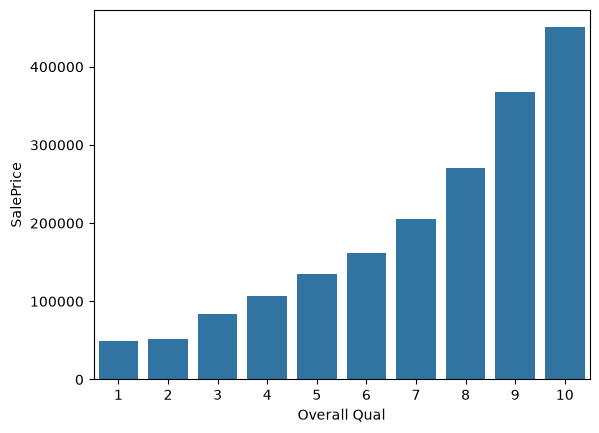

In [31]:
qual_to_price = df.groupby('Overall Qual')['SalePrice'].mean()

sns.barplot(qual_to_price)
print(qual_to_price)

**Finding — checking for curvature directly, not just eyeballing the bar
chart:** the dollar jump between consecutive quality levels is **not constant**:

| Qual | Mean Price | Jump from prior level |
|---|---|---|
| 1 | \$48,725 | — |
| 2 | \$52,325 | +\$3,600 |
| 3 | \$83,186 | +\$30,860 |
| 4 | \$106,485 | +\$23,299 |
| 5 | \$134,753 | +\$28,268 |
| 6 | \$162,130 | +\$27,377 |
| 7 | \$205,026 | +\$42,896 |
| 8 | \$270,914 | +\$65,888 |
| 9 | \$368,337 | +\$97,423 |
| 10 | \$450,217 | +\$81,880 |

If the relationship were linear, these jumps would be roughly constant. Instead
they clearly accelerate — jumps in the \$25-30K range at low-to-mid quality
balloon to \$65-97K near the top. This is real, checkable evidence of a convex
(accelerating) relationship — good justification for a polynomial term on
`Overall Qual` specifically, rather than a guess.

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

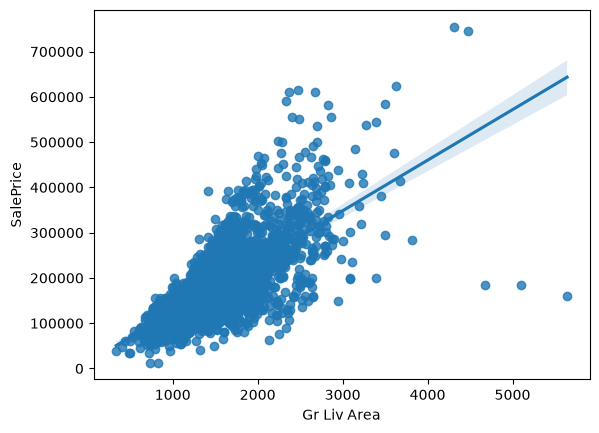

In [32]:
sns.regplot(y = 'SalePrice',x ='Gr Liv Area', data=df)

`Gr Liv Area` was also checked for comparison — visually trending upward with
a slightly steeper slope at higher values, but `Overall Qual`'s discrete jump
table above gave a much clearer, more directly quantifiable case for curvature,
so `Overall Qual` was the feature chosen for a squared term.

<Axes: xlabel='Overall Qual Sq', ylabel='SalePrice'>

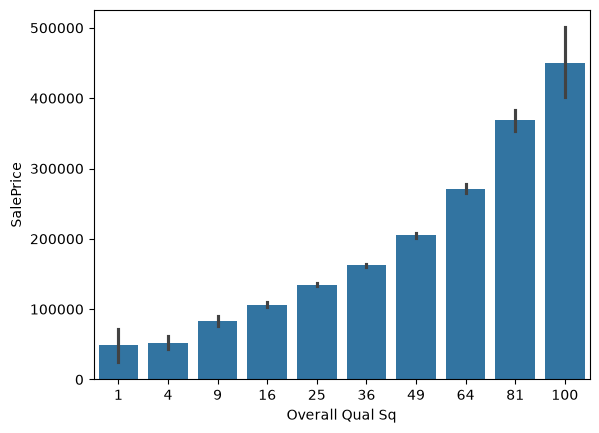

In [33]:
df['Overall Qual Sq'] = df['Overall Qual'] ** 2

sns.barplot(x = 'Overall Qual Sq', y = 'SalePrice', data = df)

**Important implementation note:** `Overall Qual Sq` is created from the
**raw** 1-10 values (`df['Overall Qual'] ** 2`) *before* scaling, and added
*alongside* the original `Overall Qual` — not in place of it. Squaring an
already-scaled (mean-centered, so sometimes negative) value would change its
meaning entirely, since both a large negative and large positive scaled value
would square to a large positive number, losing the "accelerates at the high
end" signal being targeted. Both the raw feature and its square are then scaled
together as ordinary numeric features inside `train_and_evaluate`.

**Result:** adding `Overall Qual Sq` improved the model from RMSE \$36,285 / R²
0.836 to RMSE \$34,120 / R² 0.855 — a larger single-feature gain than either
`Year Built` or `Full Bath` delivered individually, despite `Overall Qual Sq`
not being "new" raw information at all — just the same feature in a different,
better-fitting functional form. The gain came not from new raw information but from a
better-fitting functional form of a feature already in the model.

## Final Model — All Screened Features Combined

The reusable function from Stage 7, applied to the full screened feature set:
7 numeric features (including the Stage 9 polynomial term) plus one-hot encoded
`Neighborhood_fixed`, `Bsmt Qual`, and `Exter Qual`.

epoch: 0, MSE: 0.976879
epoch: 200, MSE: 0.170161
epoch: 400, MSE: 0.163590
epoch: 600, MSE: 0.160661
epoch: 800, MSE: 0.159149
epoch: 1000, MSE: 0.158317
epoch: 1200, MSE: 0.157840
epoch: 1400, MSE: 0.157556
epoch: 1600, MSE: 0.157379
epoch: 1800, MSE: 0.157265
epoch: 2000, MSE: 0.157188
epoch: 2200, MSE: 0.157134
epoch: 2400, MSE: 0.157095
epoch: 2600, MSE: 0.157066
epoch: 2800, MSE: 0.157043


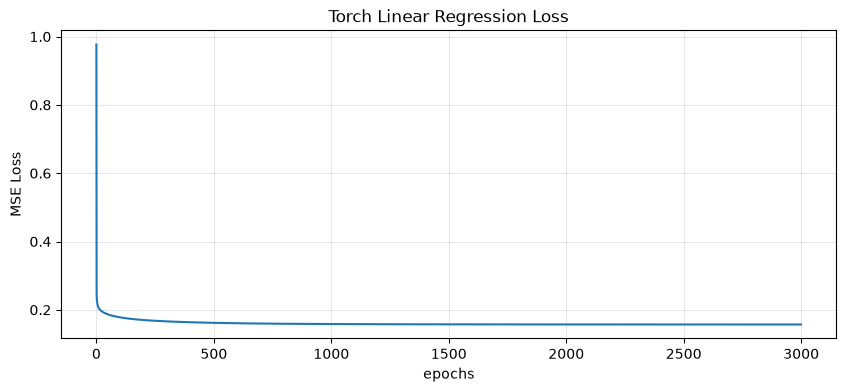

{'Torch RMSE': 32348.150390625,
 'Torch R2': 0.8694859147071838,
 'SK RMSE': 32345.94638816164,
 'SK R2': 0.8695037115135316,
 'n_features_after_encoding': 39}

In [34]:
num_features = ["Overall Qual", "Gr Liv Area", "Garage Cars", "Total Bsmt SF", "Year Built", "Full Bath", 'Overall Qual Sq']
cat_features = ["Neighborhood_fixed", 'Bsmt Qual', 'Exter Qual']

# Encode categorical columns before calling the function
cat_encoded = pd.get_dummies(df[cat_features], drop_first=True).astype(float)
X = pd.concat([df[num_features], cat_encoded], axis=1)
y = df[["SalePrice"]]

train_and_evaluate(
    X=X,
    y=y,
    num_features=num_features,
    epochs=3000,
    lr=0.1,
)

**Finding:** this run includes the final feature set — 7 numeric features
(including `Overall Qual Sq`, from Stage 9 above) plus one-hot encoded
`Neighborhood_fixed`, `Bsmt Qual`, and `Exter Qual` — landing at **RMSE ≈ \$32,348,
R² ≈ 0.870**, with Torch and sklearn agreeing to within a few dollars. This is
the best result reached in this notebook. `Bsmt Qual` and `Exter Qual` enter
here on the strength of the Stage 8 screening.

**Progress across the whole exercise:**

| Model | RMSE | R² |
|---|---|---|
| `Overall Qual` alone | \$52,878.68 | 0.651 |
| + `Gr Liv Area`, `Garage Cars` | \$43,850.73 | 0.760 |
| + `Neighborhood` | \$38,399.81 | 0.816 |
| + `Total Bsmt SF` | \$36,327.39 | 0.835 |
| + `Year Built`, `Full Bath` | \$36,285.27 | 0.836 |
| + `Overall Qual Sq` (polynomial term) | \$34,120.42 | 0.855 |
| + `Bsmt Qual`, `Exter Qual` (final) | **\$32,348.15** | **0.869** |


## Stage 10 — Limitations and Next Steps

**Validation.** All results come from a single 80/20 split with a fixed seed.
K-fold cross-validation would give more reliable estimates, particularly for
the smaller one-hot categories. In addition, the correlation and ANOVA
screening in Stages 3 and 8 used the full dataset, so the validation split is
not fully unseen with respect to feature selection — a stricter protocol would
screen on the training portion only.

**Untested feature candidates.** `Kitchen Qual` showed an eta-squared effect
size comparable to `Bsmt Qual`/`Exter Qual` in the Stage 8 screening but was
not added to the final model. Interaction terms (e.g. `Overall Qual ×
Gr Liv Area`) were considered but not tested; the same evidence-before-code
approach used for the polynomial term applies — check whether `Gr Liv Area`'s
slope on `SalePrice` genuinely differs across `Overall Qual` groups before
adding the term.

**Engineering.** The `ColumnTransformer`/`Pipeline` pattern demonstrated in
Stage 8 is the more robust way to combine scaled numeric and encoded
categorical features, and a future version of `train_and_evaluate` should
return the fitted weights and feature names so coefficient inspection is tied
to a specific run.

**Two methodological observations worth carrying forward:**

1. **Feature contributions are not additive when features are correlated.**
   `Neighborhood` alone explained 60% of variance and the 3 numeric features
   alone explained 76%, but combined they reached 82% — overlap between
   correlated features means combined performance cannot be read off the parts.

2. **When a gradient-descent model underperforms an equivalent closed-form
   model, convergence is the first suspect** — not features or data. The loss
   curve, epoch count, and learning rate should be ruled out before anything
   else is changed.